# AutoGluon SHAP Derivation

NOT WORKING

In [ ]:
# =============================================================================
# Cell 1: Notebook Preamble and Imports
# =============================================================================
# ---
# # Notebook: SHAP Analysis of the Top AutoGluon Model
#
# **Objective:**
# This notebook implements the "pragmatic approach" for explaining our AutoGluon model.
# The steps are:
# 1. Train an AutoGluon TabularPredictor on the combined pre-op and intra-op dataset.
# 2. Identify the single best-performing **Level 1** model from the ensemble.
# 3. Verify that the best L1 model is a tree-based model (like LightGBM or XGBoost).
# 4. Extract and save this L1 model for direct use with the fast `shap.TreeExplainer`.
# 5. Prepare the test data by applying AutoGluon's internal transformations.
# 6. Calculate SHAP values for the entire test set using the fast TreeExplainer.
# ---

import os
import time
import pandas as pd
import numpy as np
import pickle
import shutil # Imported for robustly deleting directories

# Make sure to install autogluon and shap if you haven't already
# !pip install -U pip
# !pip install -U "autogluon[all]" shap
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
import shap

# Set SHAP to use a javascript-based plotting method for notebooks
shap.initjs()

print("Libraries imported successfully.")


# =============================================================================
# Cell 2: Configuration and Paths
# =============================================================================
# --- Configuration ---
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# --- File Paths ---
# PLEASE UPDATE these paths to match your system
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = '/home/server/Projects/data/AKI/results/autogluon_analysis/'
NORMALIZATION_STATS_PATH = '/home/server/Projects/data/base/normalization_stats.csv'

# Create the results directory if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)

# Path to the source data
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')

# Paths to save our trained models to avoid re-training
# Path for the full AutoGluon predictor
PREDICTOR_PATH = os.path.join(RESULTS_DIR, 'autogluon_predictor_combined')
# Path for the single best model extracted from the predictor
BEST_MODEL_PATH = os.path.join(RESULTS_DIR, 'best_single_model.pkl')


print(f"Results will be saved in: {RESULTS_DIR}")


# =============================================================================
# Cell 3: Load and Split Data
# =============================================================================
print(f"Loading data from {DATA_PATH}...")
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    print("Please update the BASE_DATA_DIR variable in Cell 2.")
    # In a real notebook, you might stop execution here
    df = pd.DataFrame() # Create empty df to avoid further errors

if not df.empty:
    # Drop identifier columns that are not features
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    print("Performing an 80/20 stratified train/test split...")
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )

    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")


# =============================================================================
# Cell 4: Train or Load the Full AutoGluon Predictor
# =============================================================================
if not df.empty:
    # More robust check: The main directory AND the essential predictor.pkl must exist.
    predictor_pkl_path = os.path.join(PREDICTOR_PATH, 'predictor.pkl')
    if os.path.exists(predictor_pkl_path):
        try:
            print(f"Found existing predictor. Attempting to load from: {PREDICTOR_PATH}")
            predictor = TabularPredictor.load(PREDICTOR_PATH)
            print("Predictor loaded successfully.")
        except Exception as e:
            # Catch any error during loading (corrupted files, etc.)
            print(f"WARNING: Failed to load predictor due to an error: {e}")
            print("The saved model directory appears to be corrupted.")
            print(f"Deleting corrupted directory: {PREDICTOR_PATH}")
            shutil.rmtree(PREDICTOR_PATH) # Automatically delete the broken folder
            print("Directory deleted. The model will be retrained from scratch.")
            predictor = None # Ensure predictor is None to trigger retraining
    else:
        # This branch is taken if the main directory or the pkl file doesn't exist.
        print(f"No valid, complete predictor found at {PREDICTOR_PATH}. Training a new model.")
        predictor = None # Ensure predictor is None to trigger retraining

    if predictor is None:
        print(f"Starting training at {time.ctime()}...")
        predictor = TabularPredictor(
            label=TARGET,
            path=PREDICTOR_PATH,
            eval_metric='balanced_accuracy',
            sample_weight='balance_weight'
        )

        # --- FIX: Added `save_bag_folds=True` to ensure child models are saved ---
        predictor.fit(
            train_data=train_df,
            # time_limit=300,
            presets='best_quality',
            save_bag_folds=True, # This forces AutoGluon to keep the child models for bagged ensembles.
            num_cpus=8,
            ag_args_fit={'num_gpus': 1}
        )
        print(f"Training complete. Predictor saved to {PREDICTOR_PATH}")

    # Display the final performance summary on the test set
    print("\n--- Predictor Performance Summary ---")
    predictor.leaderboard(test_df)


# =============================================================================
# Cell 5: Identify and Verify the Best Level 1 Model
# =============================================================================
if not df.empty:
    print("\n--- Identifying the Best Level 1 Model for SHAP Analysis ---")
    
    leaderboard = predictor.leaderboard(test_df)
    
    # Filter the leaderboard to only include models from the base level (stack_level=1)
    l1_leaderboard = leaderboard[leaderboard['stack_level'] == 1]
    
    if l1_leaderboard.empty:
        raise ValueError("Could not find any Level 1 models in the leaderboard.")
        
    # Get the name of the top-performing L1 model (already sorted by score)
    best_l1_model_name = l1_leaderboard.iloc[0]['model']
    print(f"The best performing Level 1 model is: '{best_l1_model_name}'")

    # Define the model types that work with the fast shap.TreeExplainer
    acceptable_tree_models = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'ExtraTrees']

    # Check if the best model is one of our acceptable types
    if any(best_l1_model_name.startswith(prefix) for prefix in acceptable_tree_models):
        print(f"Success! The best L1 model is a tree-based model compatible with shap.TreeExplainer.")
    else:
        raise TypeError(
            f"The best L1 model '{best_l1_model_name}' is not an accepted tree-based model. "
            "This analysis plan requires a tree-based model."
        )


# =============================================================================
# Cell 6: Extract and Save the Best Single Model
# =============================================================================
if not df.empty:
    if os.path.exists(BEST_MODEL_PATH):
        print(f"\nLoading best single model from: {BEST_MODEL_PATH}")
        with open(BEST_MODEL_PATH, 'rb') as f:
            best_model = pickle.load(f)
        print("Model loaded successfully.")
    else:
        print(f"\nExtracting '{best_l1_model_name}' from the predictor...")
        # Load the chosen L1 model (which is likely a BaggedEnsemble)
        l1_model_ensemble = predictor._trainer.load_model(best_l1_model_name)

        # Check if the loaded L1 model is a bagged ensemble and unwrap it
        if hasattr(l1_model_ensemble, 'models') and l1_model_ensemble.models:
            print(f"The extracted model is a '{type(l1_model_ensemble).__name__}'. Unwrapping to get the base model object.")
            
            # The .models attribute can contain model objects OR their string names.
            # We must handle both cases.
            potential_model = l1_model_ensemble.models[0]
            
            if isinstance(potential_model, str):
                # If it's a string, it's the name. Load it from the trainer.
                print(f"Loading the underlying base model: '{potential_model}'")
                unwrapped_model = predictor._trainer.load_model(potential_model)
            else:
                # If it's not a string, it's the model object itself.
                unwrapped_model = potential_model

            print(f"Extracted the base model of type: '{type(unwrapped_model).__name__}'")
            print(f"Saving the unwrapped base model to: {BEST_MODEL_PATH}")
            with open(BEST_MODEL_PATH, 'wb') as f:
                pickle.dump(unwrapped_model, f)
            print("Base model saved successfully.")
            
            # Assign the truly unwrapped model to the variable we will use for SHAP
            best_model = unwrapped_model
        else:
            # This case handles non-bagged models, saving them directly.
            print(f"The extracted model is a simple model. Saving it directly to: {BEST_MODEL_PATH}")
            with open(BEST_MODEL_PATH, 'wb') as f:
                pickle.dump(l1_model_ensemble, f)
            print("Model saved successfully.")
            best_model = l1_model_ensemble

    # Display the model object that will be used for SHAP analysis
    print("\n--- Final Model Object for SHAP Analysis ---")
    print(best_model)
    

# =============================================================================
# Cell 7: Preprocess Data for SHAP Analysis
# =============================================================================
# The single best_model was trained on data that AutoGluon preprocessed internally.
# We must apply the exact same transformations to our test data before explaining it.
if not df.empty:
    print("\n--- Preparing Test Data for the Extracted Model ---")
    
    # Separate the features from the target variable *before* transformation
    X_test = test_df.drop(columns=[TARGET])
    y_test = test_df[TARGET]

    # Use the predictor's internal data preprocessing pipeline to transform the test set
    # This ensures the data format matches what the model was trained on.
    X_test_transformed = predictor.transform_features(X_test)
    
    print("Test data transformed successfully.")
    print(f"Shape of transformed test data: {X_test_transformed.shape}")
    

# =============================================================================
# Cell 8: Calculate SHAP Values
# =============================================================================
# Now we can use the fast TreeExplainer on our extracted LightGBM model
# and the transformed test data to calculate SHAP values for the entire test set.
if not df.empty:
    print("\n--- Calculating SHAP values using TreeExplainer ---")
    
    # 1. Create the explainer with the single, extracted tree model
    explainer = shap.TreeExplainer(best_model)
    
    # 2. Calculate the SHAP values. This will be very fast.
    #    The output is a raw numpy array.
    print(f"Starting SHAP calculation for {len(X_test_transformed)} samples at {time.ctime()}...")
    shap_values_raw = explainer.shap_values(X_test_transformed)
    print(f"SHAP calculation finished at {time.ctime()}.")

    # 3. Create a modern SHAP Explanation object. This bundles the values,
    #    base values (expected value), and the data itself into one convenient object.
    #    This is the standard object used by all modern SHAP plotting functions.
    shap_explanation = shap.Explanation(
        values=shap_values_raw,
        base_values=explainer.expected_value,
        data=X_test_transformed,
        feature_names=X_test_transformed.columns.tolist()
    )

    print("\nSHAP Explanation object created successfully.")
    print(f"SHAP values shape: {shap_explanation.values.shape}")
    print(f"Data shape: {shap_explanation.data.shape}")

# XGBoost Derivation

In [ ]:
# =============================================================================
# Cell 1: Notebook Preamble and Imports
# =============================================================================
# ---
# # Notebook: SHAP Analysis for XGBoost Model
#
# **Objective:**
# This notebook trains an XGBoost model using the specific hyperparameters
# from the benchmarking script, saves the model, and then calculates SHAP values
# for the entire test set using the fast `shap.TreeExplainer`.
# ---

import os
import time
import pandas as pd
import numpy as np
import pickle
import shutil

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap

# Set SHAP to use a javascript-based plotting method for notebooks
shap.initjs()

print("Libraries imported successfully.")


# =============================================================================
# Cell 2: Configuration and Paths
# =============================================================================
# --- Configuration ---
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# --- File Paths ---
# PLEASE UPDATE these paths to match your system
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
# Using a separate directory for XGBoost results to keep things organized
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# Create the results directory if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)

# Path to the source data
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
NORMALIZATION_STATS_PATH = '/home/server/Projects/data/base/normalization_stats.csv'

# Paths for saving the trained model and the final SHAP values
MODEL_PATH = os.path.join(RESULTS_DIR, 'xgboost_model.json')
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')


print(f"Results will be saved in: {RESULTS_DIR}")


# =============================================================================
# Cell 3: Load Hyperparameters for the 'combined' Dataset
# =============================================================================
# These are the optimized hyperparameters for XGBoost on the 'combined' dataset
# from your original benchmarking script.
hpo_params_combined = {
    'xgb': {
        'n_estimators': 1110,
        'learning_rate': 0.0172,
        'max_depth': 9,
        'subsample': 0.8281,
        'colsample_bytree': 0.7827,
        'gamma': 1.7456
    }
}
xgb_params = hpo_params_combined['xgb']
print("XGBoost hyperparameters loaded:")
print(xgb_params)


# =============================================================================
# Cell 4: Load and Split Data
# =============================================================================
print(f"\nLoading data from {DATA_PATH}...")
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    print("Please update the BASE_DATA_DIR variable in Cell 2.")
    df = pd.DataFrame()

if not df.empty:
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    print("Performing an 80/20 stratified train/test split...")
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )
    
    # Separate features (X) from the target (y)
    X_train_raw = train_df.drop(columns=[TARGET])
    y_train = train_df[TARGET]
    X_test_raw = test_df.drop(columns=[TARGET])
    y_test = test_df[TARGET]

    print(f"Training data shape: {X_train_raw.shape}")
    print(f"Test data shape: {X_test_raw.shape}")


# =============================================================================
# Cell 5: Preprocess Data (Scaling)
# =============================================================================
# Unlike AutoGluon, tree-based models like XGBoost often benefit from scaled data.
# We will scale the features before training.
if not df.empty:
    print("\n--- Scaling Data ---")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    # For creating the final SHAP explanation, it's useful to have these as DataFrames
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

    print("Training and test data have been scaled.")


# =============================================================================
# Cell 6: Train or Load the XGBoost Model
# =============================================================================
if not df.empty:
    if os.path.exists(MODEL_PATH):
        print(f"\nFound existing model. Loading from: {MODEL_PATH}")
        model = xgb.XGBClassifier()
        model.load_model(MODEL_PATH)
        print("Model loaded successfully.")
    else:
        print(f"\nNo existing model found. Training a new XGBoost model...")
        
        # Calculate the scale_pos_weight for handling class imbalance, same as the benchmark script
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1) if np.sum(y_train == 1) > 0 else 1
        print(f"Calculated scale_pos_weight for class imbalance: {scale_pos_weight:.2f}")

        # --- FIX IS HERE ---
        # The `early_stopping_rounds` parameter is now part of the constructor.
        model = xgb.XGBClassifier(
            **xgb_params,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1, # Use all available CPU cores
            early_stopping_rounds=50  # MOVED TO HERE
        )

        print("Starting model training...")
        # And it is removed from the .fit() method call below.
        model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)
        print("Model training complete.")
        
        # Save the model using its native, recommended format
        model.save_model(MODEL_PATH)
        print(f"Model saved to {MODEL_PATH}")

    print("\n--- Model Object ---")
    print(model)


# =============================================================================
# Cell 7: Calculate and Save SHAP Values
# =============================================================================
if not df.empty:
    if os.path.exists(SHAP_VALUES_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_PATH}")
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP values using TreeExplainer ---")
        
        explainer = shap.TreeExplainer(model)
        
        print(f"Starting SHAP calculation for {len(X_test_scaled)} samples at {time.ctime()}...")
        # Note: We pass the numpy array for performance, but will use the DataFrame for the explanation object
        shap_values_raw = explainer.shap_values(X_test_scaled)
        print(f"SHAP calculation finished at {time.ctime()}.")

        # Create a modern SHAP Explanation object
        shap_explanation = shap.Explanation(
            values=shap_values_raw,
            base_values=explainer.expected_value,
            data=X_test_scaled_df, # Use the scaled DataFrame here
            feature_names=X_test_scaled_df.columns.tolist()
        )
        
        print("\nSaving SHAP Explanation object...")
        with open(SHAP_VALUES_PATH, 'wb') as f:
            pickle.dump(shap_explanation, f)
        print(f"SHAP values saved to: {SHAP_VALUES_PATH}")

    print("\n--- SHAP Explanation Object Summary ---")
    print(f"SHAP values shape: {shap_explanation.values.shape}")
    print(f"Data shape: {shap_explanation.data.shape}")


# =============================================================================
# Cell 8: Calculate SHAP Explainer with Denormalized Data
# =============================================================================
# Use the same logic as before to explain SHAP values for denormalized data.
if not df.empty:
    if os.path.exists(SHAP_VALUES_DENORM_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_DENORM_PATH}")
        with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP explanation using denormalized data ---")
        
        # 1. Load normalization stats
        # TODO: df_stats only contains some features (because not everything was initially normalized).
        df_stats = pd.read_csv(NORMALIZATION_STATS_PATH)
        df_stats = df_stats.set_index('Unnamed: 0')
        if 'std' not in df_stats.columns:
            df_stats['std'] = np.sqrt(df_stats['var'])
        
        # 2. Load SHAP values from previous calculation
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        shap_values_raw = shap_explanation.values
        print("Previous SHAP values loaded successfully.")

        # 3. Denormalize the data for the raw shap values
        print("Denormalizing data for calculating shap explanation")
        features_to_unnormalize = list(set(df_stats.index) & set(shap_explanation.feature_names))
        feature_indices = [shap_explanation.feature_names.index(f) for f in features_to_unnormalize]
        data_unnorm = shap_explanation.data.to_numpy()
        for i, feature in zip(feature_indices, features_to_unnormalize):
            mean = df_stats.loc[feature, 'mean']
            std = df_stats.loc[feature, 'std']
            data_unnorm[:, i] = data_unnorm[:, i] * std + mean

        # 4. Calculate new shap explanation for denormalized values
        shap_explanation_denorm = shap.Explanation(
            values=shap_values_raw,
            base_values=shap_explanation.base_values,
            data=data_unnorm, # Use the denormed data
            feature_names=shap_explanation.feature_names
        )
        
        print("\nSaving denormalized SHAP Explanation object...")
        with open(SHAP_VALUES_DENORM_PATH, 'wb') as f:
            pickle.dump(shap_explanation_denorm, f)
        print(f"SHAP values saved to: {SHAP_VALUES_DENORM_PATH}")



Libraries imported successfully.
Results will be saved in: /home/server/Projects/data/AKI/results/xgboost_analysis/
XGBoost hyperparameters loaded:
{'n_estimators': 1110, 'learning_rate': 0.0172, 'max_depth': 9, 'subsample': 0.8281, 'colsample_bytree': 0.7827, 'gamma': 1.7456}

Loading data from /home/server/Projects/data/AKI/tabular_combined.csv...
Performing an 80/20 stratified train/test split...
Training data shape: (48659, 274)
Test data shape: (12165, 274)

--- Scaling Data ---
Training and test data have been scaled.

Found existing model. Loading from: /home/server/Projects/data/AKI/results/xgboost_analysis/xgboost_model.json
Model loaded successfully.

--- Model Object ---
XGBClassifier(base_score='5E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_wei

-----------------


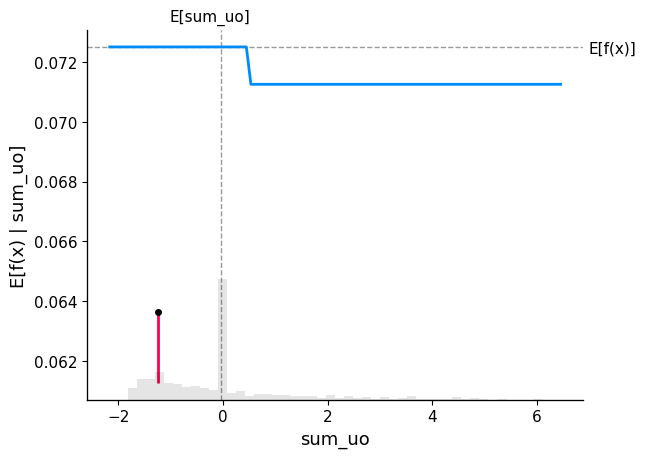

.values =
array([0.00237772])

.base_values =
array([0.06126656])

.data =
array([-1.24219104])
-----------------


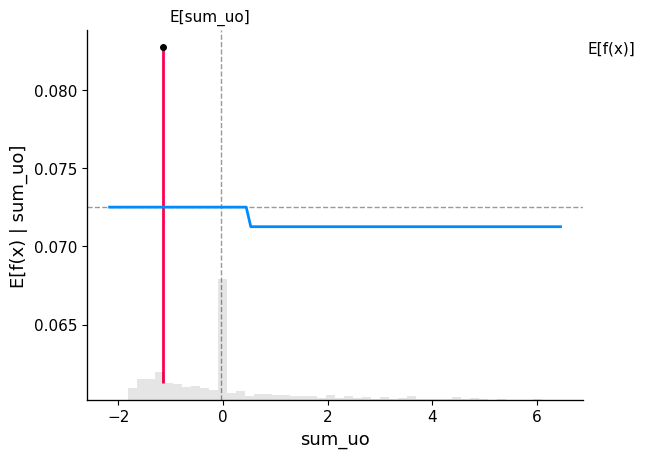

.values =
array([0.02147322])

.base_values =
array([0.06126656])

.data =
array([-1.14902994])
-----------------


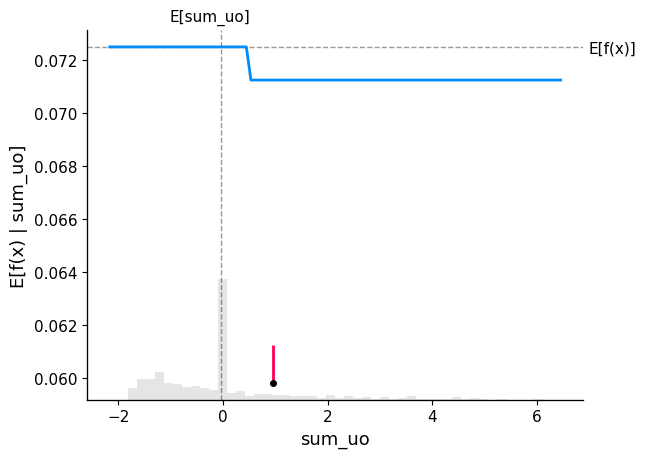

.values =
array([-0.00144448])

.base_values =
array([0.06126656])

.data =
array([0.9470948])
-----------------


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f99ee2b8b20>>
Traceback (most recent call last):
  File "/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


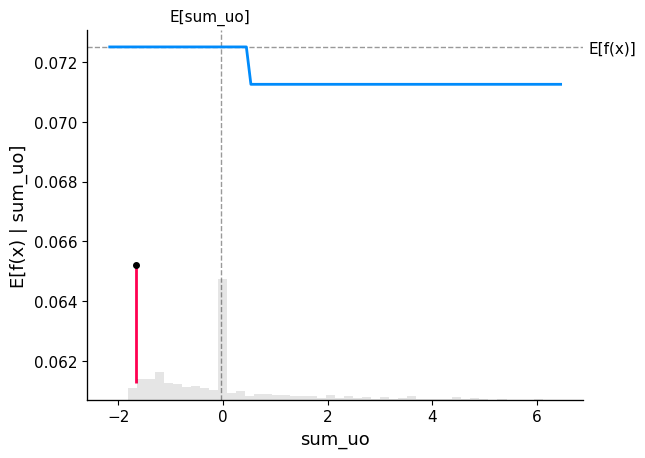

.values =
array([0.00394082])

.base_values =
array([0.06126656])

.data =
array([-1.66109979])
-----------------


In [ ]:
for sample_ind in range(5):
    print("-----------------")
    shap.partial_dependence_plot(
        "sum_uo",
        model.predict,
        X800,
        model_expected_value=True,
        feature_expected_value=True,
        ice=False,
        shap_values=shap_values[sample_ind : sample_ind + 1, :],
    )
    print(shap_values[sample_ind : sample_ind + 1, 'sum_uo'])

## Beeswarm Plot

Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation.pkl
SHAP explanation loaded successfully.

Generating beeswarm plot for top 20 features...


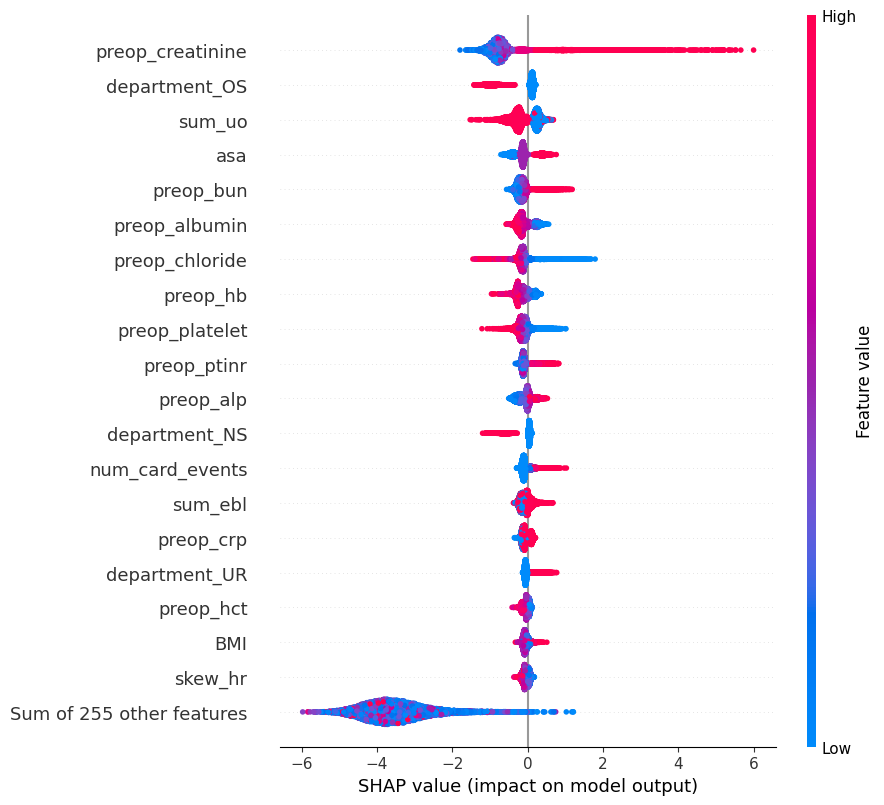

In [30]:
# =============================================================================
# Cell: Generate and Display SHAP Beeswarm Summary Plot
# =============================================================================
import os
import pickle
import shap
import matplotlib.pyplot as plt

# --- Configuration ---
# PLEASE VERIFY this path matches the results directory from your previous cells.
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# Number of top features you want to display on the plot
MAX_DISPLAY_FEATURES = 20

# --- File Paths ---
# Input: Path to the pickled SHAP explanation object
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')

# --- 1. Ensure SHAP JavaScript is initialized for interactive plots ---
# This is usually done once at the beginning of the notebook.
# Running it again is harmless.
shap.initjs()

# --- 2. Load the Pre-calculated SHAP Explanation Object ---
print(f"Loading SHAP explanation object from: {SHAP_VALUES_PATH}")

if not os.path.exists(SHAP_VALUES_PATH):
    print("\nERROR: SHAP file not found.")
    print("Please ensure you have run the main analysis notebook cell first,")
    print(f"and that the RESULTS_DIR path is set correctly.")
else:
    try:
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP explanation loaded successfully.")

        # --- 3. Generate and Display the Beeswarm Plot ---
        print(f"\nGenerating beeswarm plot for top {MAX_DISPLAY_FEATURES} features...")

        # Create a matplotlib figure to control size
        plt.figure(figsize=(12, 8))
        
        # The `show=True` default for this function will call `plt.show()`
        # which displays the plot directly in the notebook output.
        shap.plots.beeswarm(
            shap_explanation,
            max_display=MAX_DISPLAY_FEATURES
        )

    except Exception as e:
        print(f"\nAn error occurred: {e}")

# --- (Optional) 4. Save a High-Quality Copy of the Plot ---
# If you also want to save a PNG file for a presentation or paper,
# you can uncomment and run the following code in a new cell *after*
# the plot has been generated above.

# PLOT_OUTPUT_PATH = os.path.join(RESULTS_DIR, 'shap_beeswarm_summary_plot.png')
# fig = plt.gcf() # Get current figure
# fig.savefig(PLOT_OUTPUT_PATH, dpi=300, bbox_inches='tight')
# print(f"\nPlot saved to: {PLOT_OUTPUT_PATH}")
# plt.close(fig) # Close the figure to free up memory



## Positive Cases Waterfall

Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Test set labels loaded.

Found 5 positive cases to plot.
Generating a waterfall plot for each...
--------------------------------------------------
Displaying plot for Positive Case #1 (Test Set Index: 19)


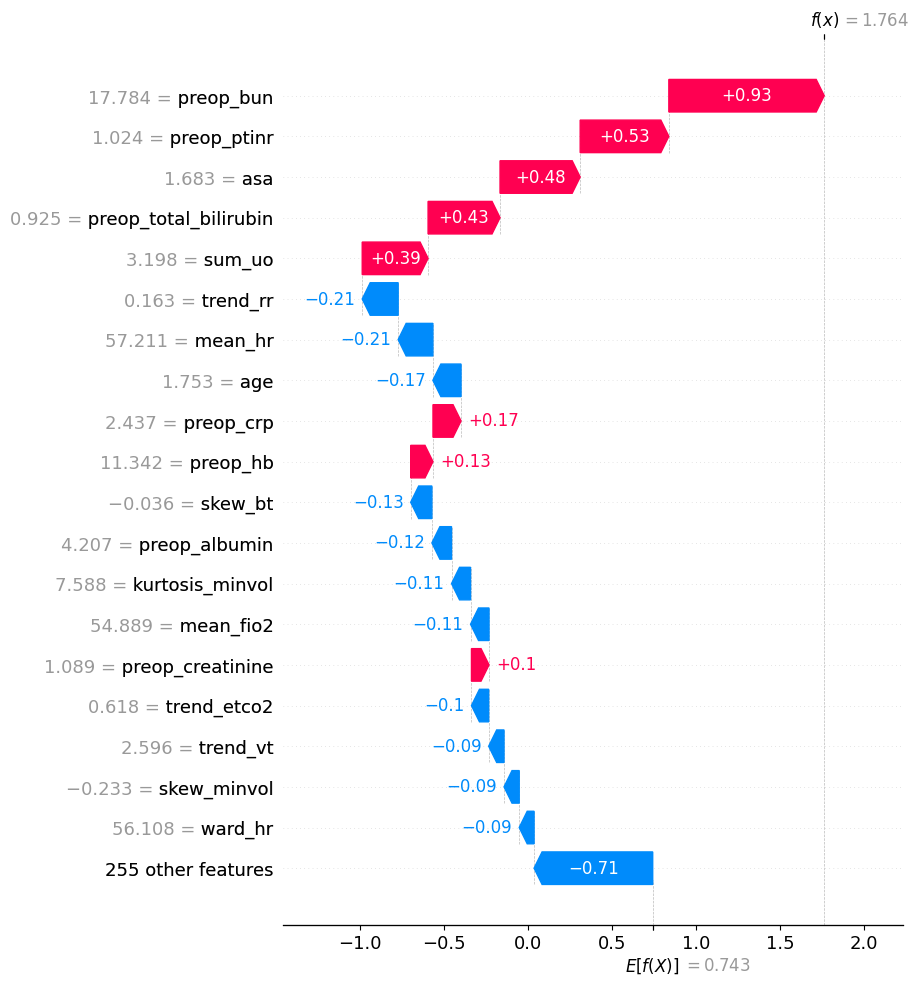

--------------------------------------------------
Displaying plot for Positive Case #2 (Test Set Index: 42)


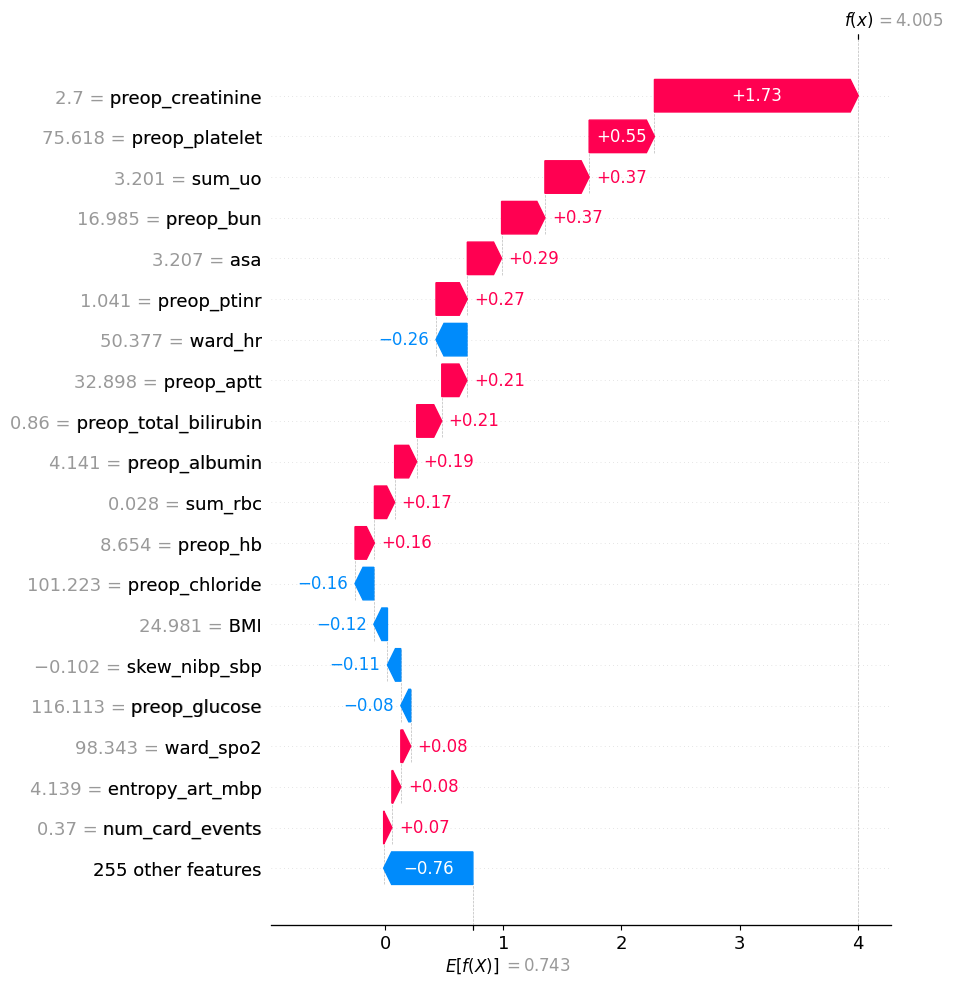

--------------------------------------------------
Displaying plot for Positive Case #3 (Test Set Index: 68)


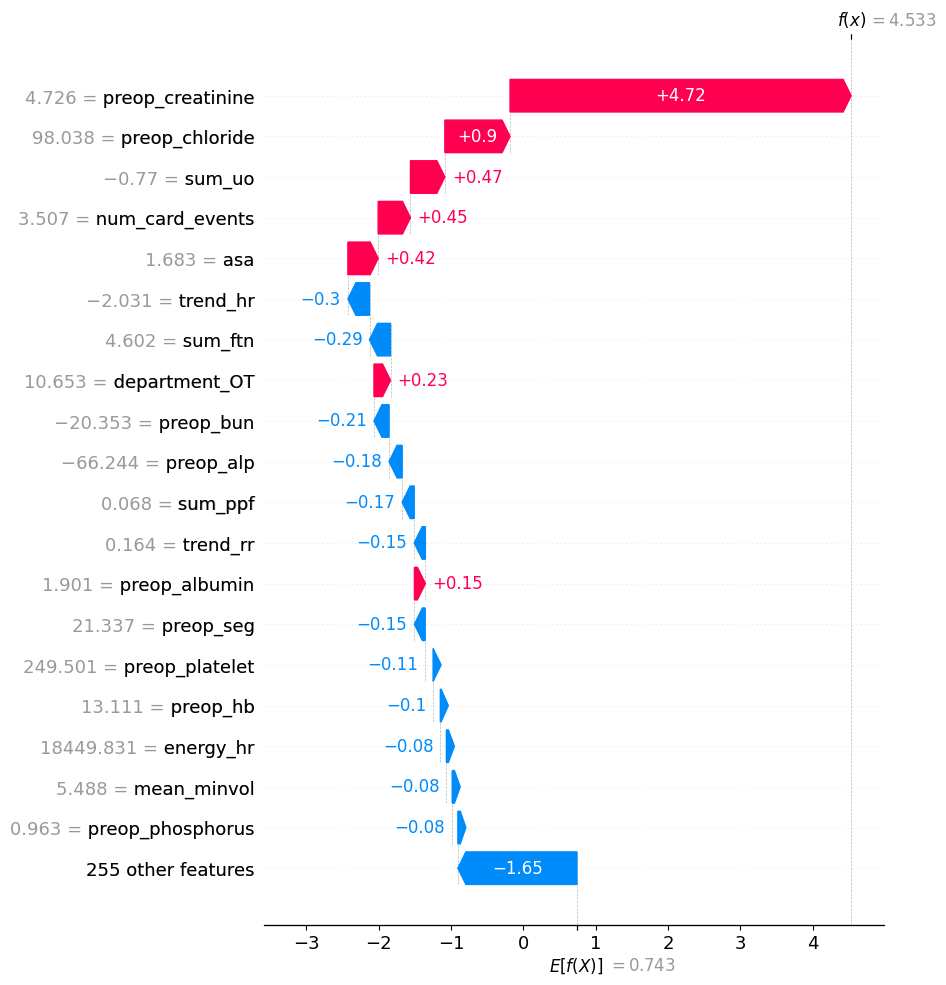

--------------------------------------------------
Displaying plot for Positive Case #4 (Test Set Index: 91)


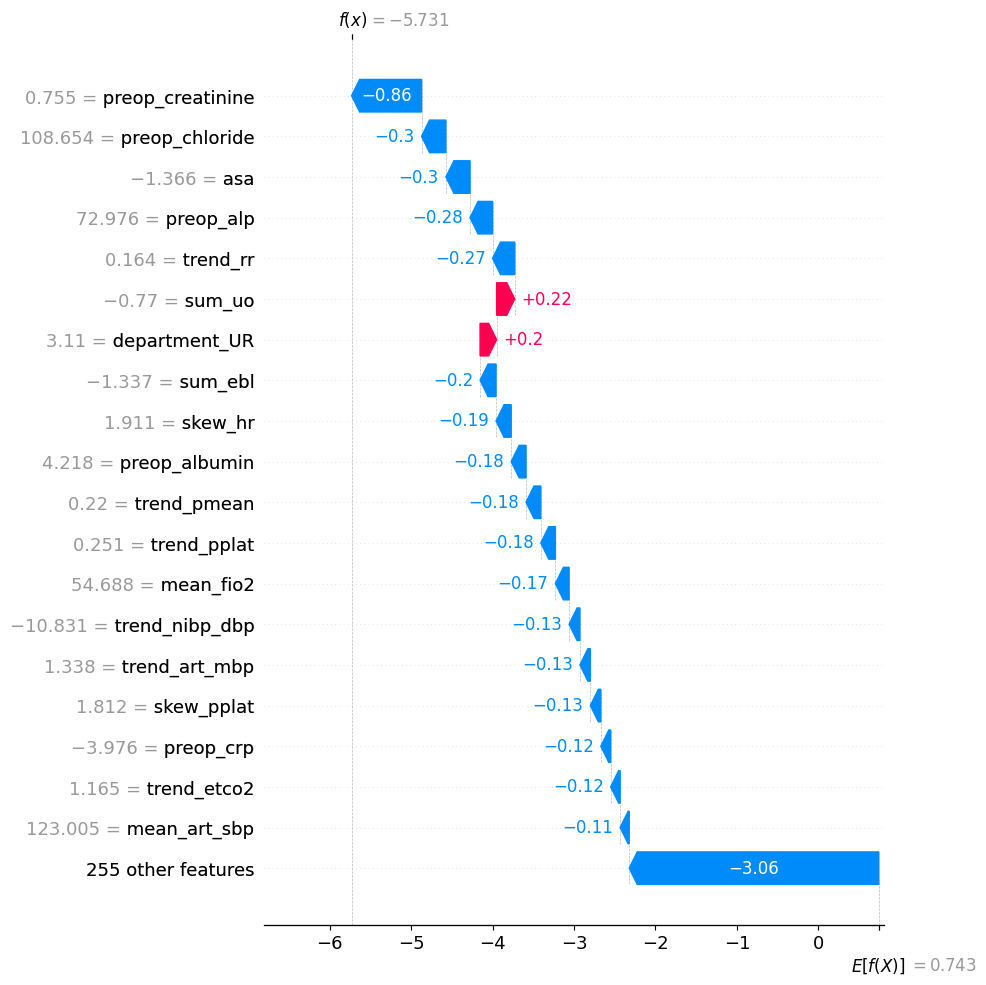

--------------------------------------------------
Displaying plot for Positive Case #5 (Test Set Index: 100)


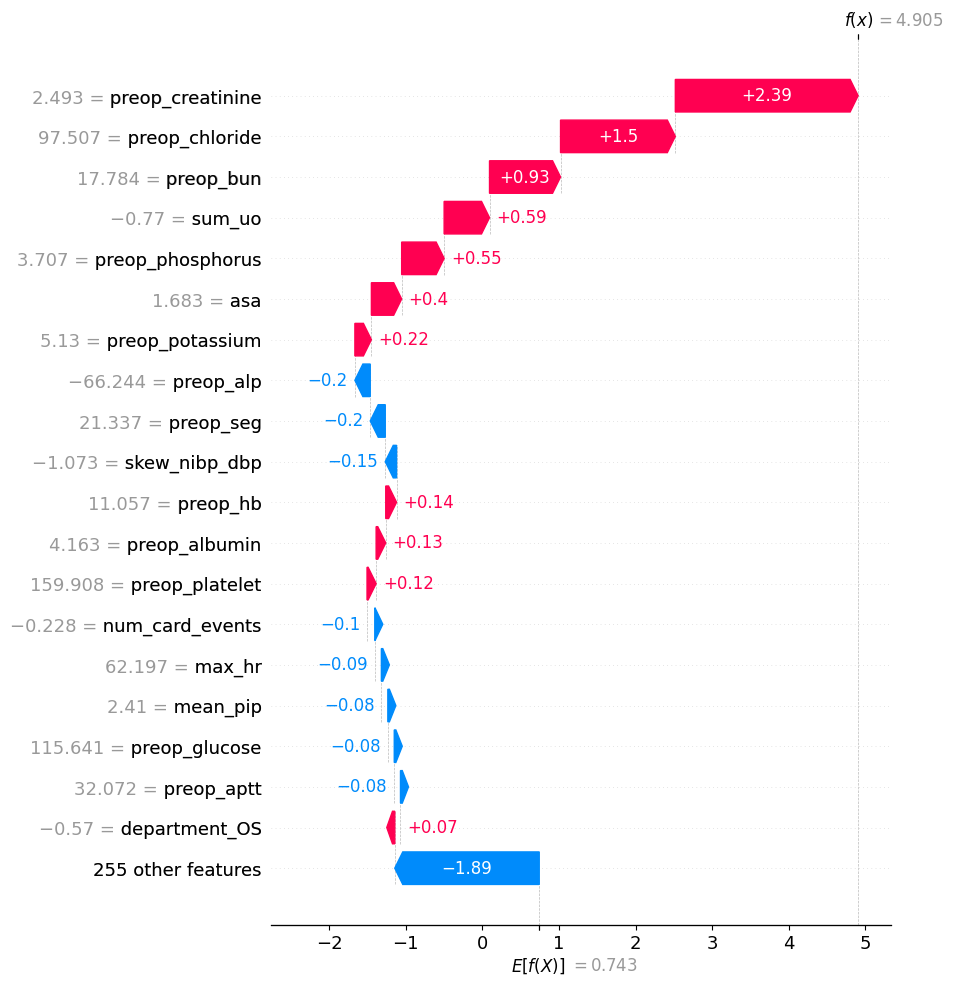

In [11]:
# =============================================================================
# Cell: Generate Waterfall Plots for Individual Positive Cases
#
# Description:
# This cell identifies samples in the test set that are positive for the
# target variable ('aki_boolean' = 1) and generates a SHAP waterfall plot
# for each one. A waterfall plot provides a detailed, step-by-step
# explanation of how each feature contributed to the final prediction for a
# single observation.
# =============================================================================
import os
import pickle
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# How many positive cases do you want to plot?
NUM_PLOTS_TO_GENERATE = 5

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')

# --- 1. Load SHAP Explanation Object ---
# We load the denormalized explanation object so that our values are clinically meaningful
print(f"Loading SHAP explanation object from: {SHAP_VALUES_DENORM_PATH}")
if not os.path.exists(SHAP_VALUES_DENORM_PATH):
    print(f"\nERROR: SHAP file not found at {SHAP_VALUES_DENORM_PATH}")
else:
    with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
        shap_explanation = pickle.load(f)
    print("SHAP explanation loaded successfully.")

    # --- 2. Reload Original Data to get the y_test labels ---
    # We need the true outcomes (y_test) to identify the positive cases.
    # To ensure we get the *exact same* test set, we must repeat the
    # train/test split using the same data and the same RANDOM_STATE.
    print(f"\nReloading data from {DATA_PATH} to get test set labels...")
    df = pd.read_csv(DATA_PATH)
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    # Perform the exact same stratified split as in the original notebook
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )
    y_test = test_df[TARGET]
    # Reset index to align with the SHAP explanation object (which is 0-indexed)
    y_test = y_test.reset_index(drop=True)
    print("Test set labels loaded.")

    # --- 3. Find Positive Cases and Generate Plots ---
    # Find the indices of the first N positive cases in the test set
    positive_case_indices = y_test[y_test == 1].head(NUM_PLOTS_TO_GENERATE).index

    print(f"\nFound {len(positive_case_indices)} positive cases to plot.")
    print("Generating a waterfall plot for each...")

    if len(positive_case_indices) == 0:
        print("\nNo positive cases found in the first part of the test set.")
    else:
        # Loop through the identified positive cases
        for i, idx in enumerate(positive_case_indices):
            print("-" * 50)
            print(f"Displaying plot for Positive Case #{i+1} (Test Set Index: {idx})")

            # A waterfall plot is the modern, standard way to show a single explanation
            shap.plots.waterfall(shap_explanation[idx], max_display=20)



# Interaction Plots

Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Plotting Interaction Plots for 10 feature names
Calculating trendline failed


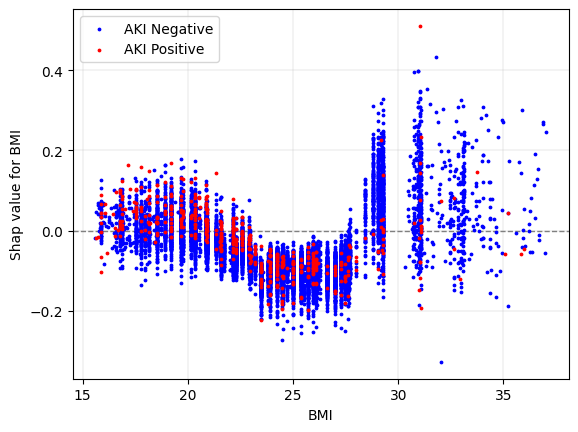

Calculating trendline failed


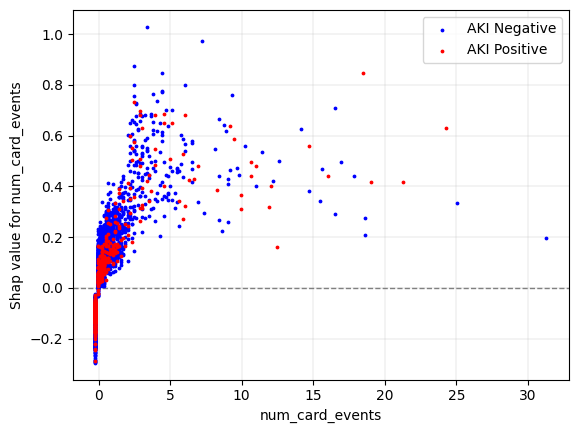

Calculating trendline failed


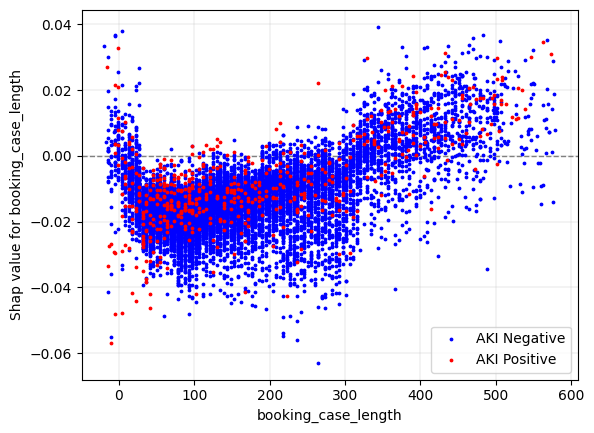

Calculating trendline failed


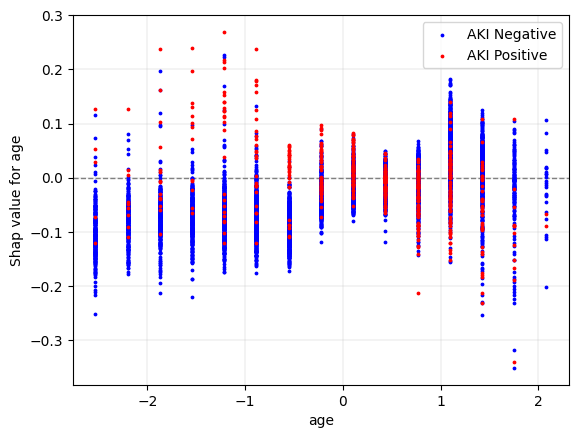

Calculating trendline failed


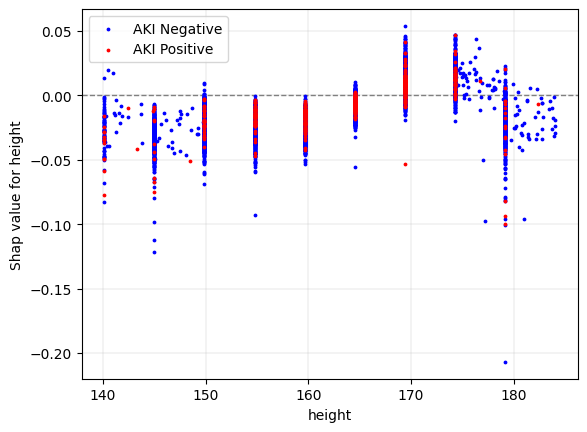

Calculating trendline failed


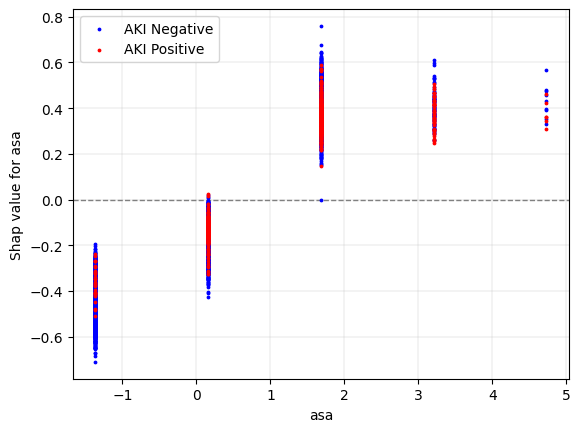

Calculating trendline failed


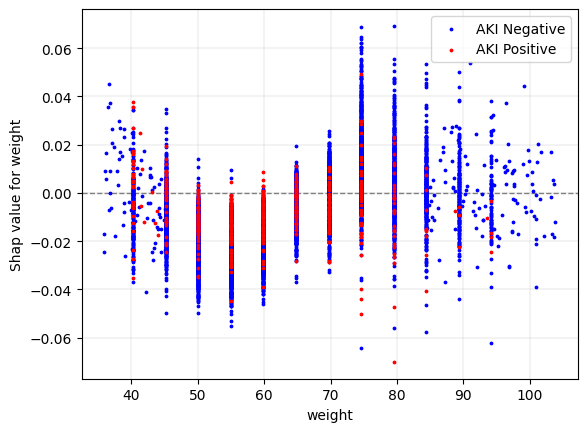

Calculating trendline failed


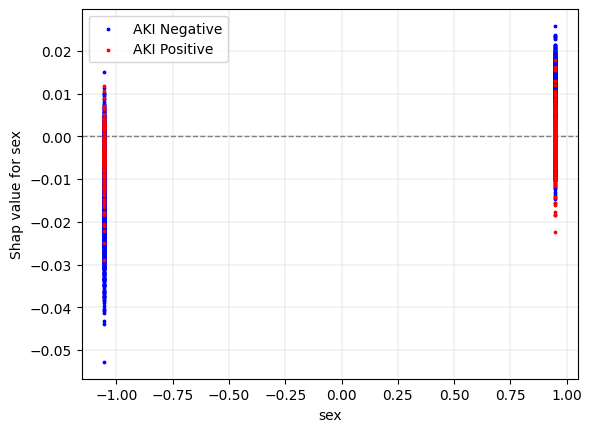

Calculating trendline failed


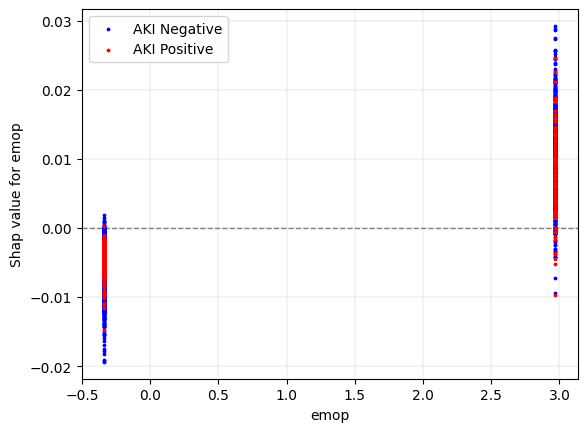

Calculating trendline failed


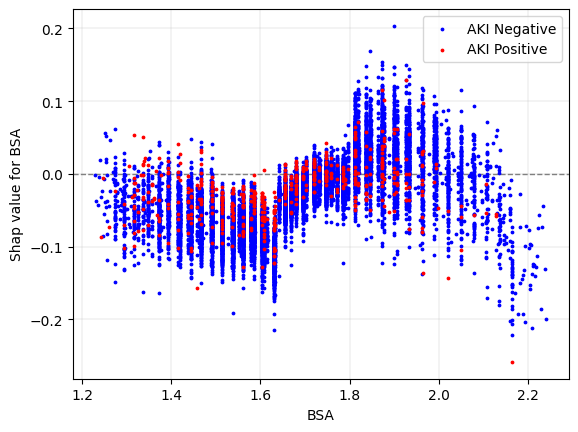

In [3]:
# =============================================================================
# Cell: Generate Interaction Plots for all Variables
#
# Description:
# This cell iterates through all variables in the dataset and produces
# interaction plots (variable value vs SHAP(variable value))
# =============================================================================
import os
import pickle
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')

# --- Helper function to plot interaction plot for specific feature ---
# See the below code for an example on how to use this function
def scatter(shap_explanation, feature_name, y):
    # get values to graph in array form
    feature_index = list(shap_explanation.feature_names).index(feature_name)
    shap_vals = shap_explanation.values[:, feature_index]
    feature_vals = shap_explanation.data[:, feature_index]

    # plot AKI pos and neg points
    plt.scatter(feature_vals[~y], shap_vals[~y], s=3, zorder=3, color='b', label='AKI Negative')
    plt.scatter(feature_vals[y], shap_vals[y], s=3, zorder=3, color='r', label='AKI Positive')

    # try to calculate trendline
    trend_x = None
    trendline = None
    label = None
    try:
        min_x = min(feature_vals)
        max_x = max(feature_vals)
        trend_x = np.linspace(min_x, max_x, 100)
        slope, intercept, r_value, p_value, std_err = linregress(feature_vals, shap_vals)
        trendline = slope * trend_x + intercept
        x_intercept = -1 * intercept / slope
        label=f'Trendline, intercept at x = {x_intercept:0.02f}'
    except:
        print("Calculating trendline failed")

    # plot trendline and finalize plot
    if trend_x is not None:
        plt.plot(trend_x, trendline, color='black', label=label, lw=2, zorder=5)
    plt.grid(True, linewidth=0.2, zorder=0)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.xlabel(feature_name)
    plt.ylabel('Shap value for ' + feature_name)
    plt.show()

# --- 1. Load SHAP Explanation Object ---
# We load the denormalized explanation object so that our values are clinically meaningful
print(f"Loading SHAP explanation object from: {SHAP_VALUES_DENORM_PATH}")
if not os.path.exists(SHAP_VALUES_DENORM_PATH):
    print(f"\nERROR: SHAP file not found at {SHAP_VALUES_DENORM_PATH}")
else:
    with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
        shap_explanation = pickle.load(f)
    print("SHAP explanation loaded successfully.")

    # --- 2. Reload Original Data to get the y_test labels ---
    # We need the true outcomes (y_test) to plot the actual outcomes.
    # To ensure we get the *exact same* test set, we must repeat the
    # train/test split using the same data and the same RANDOM_STATE.
    print(f"\nReloading data from {DATA_PATH} to get test set labels...")
    df = pd.read_csv(DATA_PATH)
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    # Perform the exact same stratified split as in the original notebook
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )
    y_test = test_df.pop(TARGET)

    # --- 3. List all Feature Names and Generate Plots ---
    # JUSTIN GET RID OF THE "[:10]" TO PLOT ALL GRAPHS, THE FILE TAKES TOO LONG TO SAVE IF I INCLUDE ALL OF THEM
    all_feature_names = set(shap_explanation.feature_names[:10])
    print(f"Plotting Interaction Plots for {len(all_feature_names)} feature names")
    for feature_name in all_feature_names:
        scatter(shap_explanation, feature_name, y_test)



## Partial Dependence Plot - NOT WORKING

Not working

Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation.pkl
SHAP explanation loaded successfully.

Generating SHAP dependence plot for feature: 'age'...

An error occurred: The ax parameter is not supported when plotting multiple features


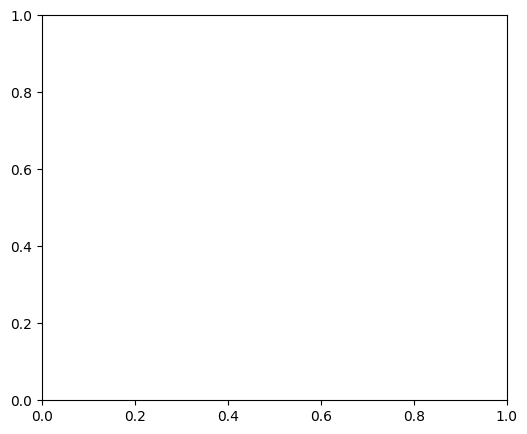

In [37]:
# =============================================================================
# Cell: Generate and Display SHAP Partial Dependence / Scatter Plot
# =============================================================================
import os
import pickle
import shap
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# PLEASE VERIFY this path matches the results directory from your previous cells.
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# <<< CHOOSE YOUR FEATURE >>>
# UPDATE this variable to the name of the feature you want to plot.
# The feature name must exist in your dataset.
# Examples from your previous code: "min_preop_scr", "age", "BMI", "preop_potassium"
FEATURE_TO_PLOT = "age" 

# --- File Paths ---
# Input: Path to the pickled SHAP explanation object
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')

# --- 1. Load the Pre-calculated SHAP Explanation Object ---
print(f"Loading SHAP explanation object from: {SHAP_VALUES_PATH}")

if not os.path.exists(SHAP_VALUES_PATH):
    print("\nERROR: SHAP file not found.")
    print("Please ensure you have run the main analysis notebook cell first,")
    print(f"and that the RESULTS_DIR path is set correctly.")
else:
    try:
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP explanation loaded successfully.")

        # --- 2. Generate and Display the Dependence Scatter Plot ---
        print(f"\nGenerating SHAP dependence plot for feature: '{FEATURE_TO_PLOT}'...")
        
        # Check if the chosen feature exists
        if FEATURE_TO_PLOT not in shap_explanation.feature_names:
            print(f"\nERROR: Feature '{FEATURE_TO_PLOT}' not found in the dataset.")
            print(f"Please choose a valid feature name.")
        else:
            # --- FIX APPLIED HERE ---
            # The line `plt.figure(...)` has been removed.
            # We let the shap library handle the creation of the figure and axes
            # to avoid conflicts when it plots interacting features.
            
            # To address version incompatibilities, we get the slice for the
            # specific feature, then create a *new* Explanation object for plotting.
            sliced_expl = shap_explanation[:, FEATURE_TO_PLOT]

            # The plotting function expects the data to be a 2D array (n_samples, n_features).
            # When we slice for one feature, the data becomes a 1D array.
            # We must reshape it to be a 2D array with one column.
            feature_data_reshaped = sliced_expl.data.values.reshape(-1, 1)

            plot_explanation_slice = shap.Explanation(
                values=sliced_expl.values,
                base_values=sliced_expl.base_values,
                data=feature_data_reshaped, # Use the reshaped 2D array
                feature_names=[FEATURE_TO_PLOT] # Must be a list
            )

            # Generate the plot using the newly created explanation object.
            # The color argument still uses the original full explanation object
            # to automatically find the strongest interacting feature.
            shap.plots.scatter(
                plot_explanation_slice,
                color=shap_explanation
            )

    except Exception as e:
        print(f"\nAn error occurred: {e}")

# --- (Optional) 3. Save a High-Quality Copy of the Plot ---
# If you also want to save a PNG file, you can uncomment and run this code
# in a new cell *after* the plot has been generated above.

# PLOT_OUTPUT_PATH = os.path.join(RESULTS_DIR, f'shap_dependence_plot_{FEATURE_TO_PLOT}.png')
# fig = plt.gcf() # Get current figure
# fig.savefig(PLOT_OUTPUT_PATH, dpi=300, bbox_inches='tight')
# print(f"\nPlot saved to: {PLOT_OUTPUT_PATH}")
# plt.close(fig) # Close the figure to free up memory
